In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
IMAGE_DIR = "../data/images/LungcancerDataSet/Data/test/adenocarcinoma"

In [ ]:
images = os.listdir(IMAGE_DIR)

plt.figure(figsize=(12, 5))

for i, img_name in enumerate(images[:5]):
    img_path = os.path.join(IMAGE_DIR, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(img_name)
    plt.axis("off")

plt.show()


In [ ]:
print("Number of images in this class:", len(images))
print("Image shape:", img.shape)
print("Pixel range:", img.min(), "-", img.max())


In [ ]:
import numpy as np

# Resize parameters
IMG_SIZE = 224  # standard for CNNs

# Take one image for demo
sample_img_path = os.path.join(IMAGE_DIR, images[0])
img = cv2.imread(sample_img_path, cv2.IMREAD_GRAYSCALE)

# Resize
img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

# Normalize
img_normalized = img_resized / 255.0

print("Resized shape:", img_resized.shape)
print("Normalized pixel range:", img_normalized.min(), "-", img_normalized.max())


In [ ]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original CT Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_normalized, cmap="gray")
plt.title("Preprocessed CT Image")
plt.axis("off")

plt.show()


In [ ]:
img_denoised = cv2.GaussianBlur(img_normalized, (5, 5), 0)

plt.imshow(img_denoised, cmap="gray")
plt.title("Denoised CT Image")
plt.axis("off")
plt.show()


In [3]:
def load_dataset(base_dir, img_size=224):
    X = []
    y = []
    class_names = sorted(os.listdir(base_dir))

    for label, class_name in enumerate(class_names):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img = cv2.resize(img, (img_size, img_size))
            img = img / 255.0

            X.append(img)
            y.append(label)

    return np.array(X), np.array(y), class_names


In [ ]:
TRAIN_DIR = "../data/images/LungcancerDataSet/Data/train"

X_train, y_train, class_names = load_dataset(TRAIN_DIR)

print("Classes:", class_names)
print("Training samples:", X_train.shape)
print("Training labels:", y_train.shape)


In [ ]:
X_train = X_train[..., np.newaxis]

print("Final training shape:", X_train.shape)


In [ ]:
import pandas as pd

pd.Series(y_train).value_counts().rename(index=dict(enumerate(class_names)))


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
num_classes = len(class_names)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.summary()


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
VALID_DIR = "../data/images/LungcancerDataSet/Data/valid"

X_val, y_val, _ = load_dataset(VALID_DIR)
X_val = X_val[..., np.newaxis]

print("Validation shape:", X_val.shape)


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=16,
    callbacks=[early_stop]
)


In [ ]:
model.save("../models/lung_cancer_cnn.h5")


In [ ]:
TEST_DIR = "../data/images/LungcancerDataSet/Data/test"

X_test, y_test, _ = load_dataset(TEST_DIR)
X_test = X_test[..., np.newaxis]

print("Test shape:", X_test.shape)


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)


In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred_classes, target_names=class_names))


In [4]:
def load_binary_dataset(base_dir, img_size=224):
    X = []
    y = []

    for class_name in os.listdir(base_dir):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        # Normal = 0, Cancer = 1
        label = 0 if class_name.lower() == "normal" else 1

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            img = cv2.resize(img, (224, 224))
            img = img / 255.0

            X.append(img)
            y.append(label)

    return np.array(X), np.array(y)


In [5]:
X_train_bin, y_train_bin = load_binary_dataset(
    "../data/images/LungcancerDataSet/Data/train"
)

X_val_bin, y_val_bin = load_binary_dataset(
    "../data/images/LungcancerDataSet/Data/valid"
)

X_test_bin, y_test_bin = load_binary_dataset(
    "../data/images/LungcancerDataSet/Data/test"
)

X_train_bin = X_train_bin[..., np.newaxis]
X_val_bin   = X_val_bin[..., np.newaxis]
X_test_bin  = X_test_bin[..., np.newaxis]

print("Binary train shape:", X_train_bin.shape)
print("Binary labels:", np.unique(y_train_bin))


Binary train shape: (1460, 224, 224, 1)
Binary labels: [0 1]


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

model_bin = Sequential([
    Input(shape=(224, 224, 1)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_bin.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_bin.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 186624)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │      11,944,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,962,881 (45.63 MB)

 Trainable params: 11,962,881 (45.63 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_bin = model_bin.fit(
    X_train_bin, y_train_bin,
    validation_data=(X_val_bin, y_val_bin),
    epochs=10,
    batch_size=16,
    callbacks=[early_stop]
)


Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 81s 844ms/step - accuracy: 0.7884 - loss: 0.4901 - val_accuracy: 0.8873 - val_loss: 0.3604
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 78s 845ms/step - accuracy: 0.9658 - loss: 0.1109 - val_accuracy: 0.9014 - val_loss: 0.3853
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 72s 777ms/step - accuracy: 0.9877 - loss: 0.0487 - val_accuracy: 0.8803 - val_loss: 0.5344
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 164ms/step - accuracy: 0.9897 - loss: 0.0303 - val_accuracy: 0.9014 - val_loss: 0.6026


In [8]:
test_loss, test_acc = model_bin.evaluate(X_test_bin, y_test_bin)
print("Binary Test Accuracy:", test_acc)


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.8316 - loss: 0.3816
Binary Test Accuracy: 0.8315789699554443


In [9]:
model_bin.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 186624)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │      11,944,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 35,888,645 (136.90 MB)

 Trainable params: 11,962,881 (45.63 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 23,925,764 (91.27 MB)

In [10]:
import tensorflow as tf

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


In [12]:
# Force model to build its computation graph
_ = model_bin.predict(X_test_bin[:1])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


In [13]:
for layer in model_bin.layers:
    print(layer.name, layer.__class__.__name__)


conv2d Conv2D
max_pooling2d MaxPooling2D
conv2d_1 Conv2D
max_pooling2d_1 MaxPooling2D
flatten Flatten
dense Dense
dropout Dropout
dense_1 Dense


In [14]:
last_conv_layer_name = "conv2d_1"  # replace if different

img = X_test_bin[0]
img_input = np.expand_dims(img, axis=0)

heatmap = make_gradcam_heatmap(
    img_input, model_bin, last_conv_layer_name
)

heatmap = cv2.resize(heatmap, (224, 224))

plt.imshow(img.squeeze(), cmap='gray')
plt.imshow(heatmap, cmap='jet', alpha=0.4)
plt.title("Grad-CAM Explanation")
plt.axis("off")
plt.show()


AttributeError: The layer sequential has never been called and thus has no defined output.

In [15]:
# Force model to build its computation graph
_ = model_bin(X_test_bin[:1], training=False)


In [16]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Ensure model is built
    _ = model(img_array)

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.math.reduce_max(heatmap) + 1e-10

    return heatmap.numpy()


In [17]:
last_conv_layer_name = "conv2d_1"

img = X_test_bin[0]
img_input = np.expand_dims(img, axis=0)

heatmap = make_gradcam_heatmap(
    img_input, model_bin, last_conv_layer_name
)

heatmap = cv2.resize(heatmap, (224, 224))

plt.imshow(img.squeeze(), cmap='gray')
plt.imshow(heatmap, cmap='jet', alpha=0.4)
plt.title("Grad-CAM Explanation")
plt.axis("off")
plt.show()


AttributeError: The layer sequential has never been called and thus has no defined input.

In [18]:
# Rebuild a functional model wrapper (no retraining)
inputs = tf.keras.Input(shape=(224, 224, 1))
x = inputs

for layer in model_bin.layers:
    x = layer(x)

grad_model_wrapper = tf.keras.Model(inputs, x)


In [19]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Create grad model from wrapper
    grad_model = tf.keras.models.Model(
        inputs=grad_model_wrapper.input,
        outputs=[
            grad_model_wrapper.get_layer(last_conv_layer_name).output,
            grad_model_wrapper.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.math.reduce_max(heatmap) + 1e-10

    return heatmap.numpy()


In [20]:
last_conv_layer_name = "conv2d_1"

img = X_test_bin[0]
img_input = np.expand_dims(img, axis=0)

heatmap = make_gradcam_heatmap(
    img_input, model_bin, last_conv_layer_name
)

heatmap = cv2.resize(heatmap, (224, 224))

plt.imshow(img.squeeze(), cmap='gray')
plt.imshow(heatmap, cmap='jet', alpha=0.4)
plt.title("Grad-CAM Explanation")
plt.axis("off")
plt.show()


KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m1746456199024\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[0.00392157],\n         [0.        ],\n         [0.        ],\n         ...,\n         [0.        ],\n         [0.        ],\n         [0.        ]],\n\n        [[0.        ],\n         [0.        ],\n         [0.        ],\n         ...,\n         [0.        ],\n         [0.        ],\n         [0.        ]],\n\n        [[0.        ],\n         [0.        ],\n         [0.        ],\n         ...,\n         [0.        ],\n         [0.        ],\n         [0.        ]],\n\n        ...,\n\n        [[0.        ],\n         [0.        ],\n         [0.        ],\n         ...,\n         [0.        ],\n         [0.        ],\n         [0.        ]],\n\n        [[0.        ],\n         [0.        ],\n         [0.        ],\n         ...,\n         [0.        ],\n         [0.        ],\n         [0.        ]],\n\n        [[0.        ],

In [21]:
def generate_saliency_map(model, img_array):
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        predictions = model(img_tensor)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, img_tensor)

    saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0]
    saliency = saliency.numpy()

    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-10)
    return saliency


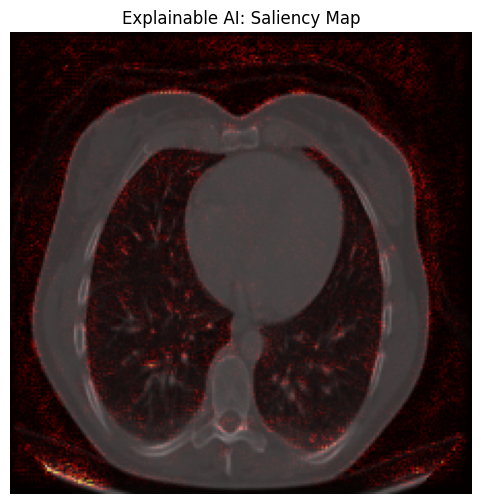

In [22]:
img = X_test_bin[0]
img_input = np.expand_dims(img, axis=0)

saliency_map = generate_saliency_map(model_bin, img_input)

plt.figure(figsize=(6,6))
plt.imshow(img.squeeze(), cmap='gray')
plt.imshow(saliency_map, cmap='hot', alpha=0.5)
plt.title("Explainable AI: Saliency Map")
plt.axis("off")
plt.show()


In [23]:
def predict_with_explanation(model, img_array, threshold=0.5):
    prediction = model.predict(img_array)[0][0]
    
    if prediction >= threshold:
        label = "Cancer Detected"
        risk = "High"
        explanation = (
            "The model has identified abnormal lung tissue patterns "
            "that are commonly associated with early-stage lung cancer. "
            "Highlighted regions indicate areas of concern."
        )
    else:
        label = "Normal"
        risk = "Low"
        explanation = (
            "The model did not detect significant abnormal lung patterns. "
            "No major regions of concern were identified."
        )

    confidence = round(float(prediction) * 100, 2)

    return {
        "label": label,
        "risk_level": risk,
        "confidence": confidence,
        "explanation": explanation
    }


In [24]:
img = X_test_bin[0]
img_input = np.expand_dims(img, axis=0)

result = predict_with_explanation(model_bin, img_input)
print(result)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
{'label': 'Cancer Detected', 'risk_level': 'High', 'confidence': 96.02, 'explanation': 'The model has identified abnormal lung tissue patterns that are commonly associated with early-stage lung cancer. Highlighted regions indicate areas of concern.'}


In [25]:
def calculate_behavior_risk(smoking_years, cigarettes_per_day, age, pollution_exposure):
    score = 0

    score += smoking_years * 1.5
    score += cigarettes_per_day * 2
    score += (age - 30) * 0.5 if age > 30 else 0
    score += pollution_exposure * 10  # 0–5 scale

    if score < 50:
        risk = "Low"
    elif score < 100:
        risk = "Medium"
    else:
        risk = "High"

    return round(score, 2), risk


In [26]:
behavior_score, behavior_risk = calculate_behavior_risk(
    smoking_years=10,
    cigarettes_per_day=5,
    age=45,
    pollution_exposure=3
)

print("Behavior Risk Score:", behavior_score)
print("Behavior Risk Level:", behavior_risk)


Behavior Risk Score: 62.5
Behavior Risk Level: Medium


In [27]:
def generate_recommendations(ai_result, behavior_risk):
    recommendations = []

    if ai_result["risk_level"] == "High" or behavior_risk == "High":
        recommendations.append("Consult a pulmonologist or oncologist immediately.")
        recommendations.append("Schedule a high-resolution CT scan and biopsy if advised.")
        recommendations.append("Avoid smoking and exposure to air pollution.")
        recommendations.append("Begin a healthy diet rich in antioxidants.")
    
    elif ai_result["risk_level"] == "Low" and behavior_risk == "Medium":
        recommendations.append("Monitor lung health with periodic CT scans.")
        recommendations.append("Reduce smoking and avoid second-hand smoke.")
        recommendations.append("Increase physical activity and breathing exercises.")
    
    else:
        recommendations.append("Maintain a healthy lifestyle.")
        recommendations.append("Avoid smoking and polluted environments.")
        recommendations.append("Schedule regular health check-ups.")
    
    return recommendations


In [28]:
img = X_test_bin[0]
img_input = np.expand_dims(img, axis=0)

ai_result = predict_with_explanation(model_bin, img_input)

behavior_score, behavior_risk = calculate_behavior_risk(
    smoking_years=12,
    cigarettes_per_day=8,
    age=48,
    pollution_exposure=4
)

recommendations = generate_recommendations(ai_result, behavior_risk)

print("AI Result:", ai_result)
print("Behavior Risk:", behavior_risk)
print("Recommendations:")
for rec in recommendations:
    print("-", rec)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
AI Result: {'label': 'Cancer Detected', 'risk_level': 'High', 'confidence': 96.02, 'explanation': 'The model has identified abnormal lung tissue patterns that are commonly associated with early-stage lung cancer. Highlighted regions indicate areas of concern.'}
Behavior Risk: Medium
Recommendations:
- Consult a pulmonologist or oncologist immediately.
- Schedule a high-resolution CT scan and biopsy if advised.
- Avoid smoking and exposure to air pollution.
- Begin a healthy diet rich in antioxidants.
